### Import packages

In [ ]:
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
import numpy as np


### EDA

1. LOAD DATA

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_8088/2634253260.py:2: DtypeWarning: Columns (42,43,44,45,46,47,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
data.columns

Index(['weight', 'BNPL1', 'BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d',
       'BNPL4_e', 'BNPL4_f', 'EF3_a', 'EF3_b', 'EF3_c', 'EF3_d', 'EF3_e',
       'EF3_f', 'EF3_g', 'EF3_h', 'I20', 'ppfs0596', 'ppeducat', 'ppage',
       'ppagecat', 'ppethm', 'ppgender', 'ppinc7', 'ppemploy', 'ppmarit5',
       'pphhsize', 'ppkid017', 'ppfs1482', 'SL6', 'B3', 'A6', 'C4A', 'EF1',
       'L0C', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b',
       'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C', 'year'],
      dtype='object')

2. Check columns

In [ ]:
columns = ['BNPL1', 'BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d',
       'BNPL4_e', 'BNPL4_f', 'EF3_a', 'EF3_b', 'EF3_c', 'EF3_d', 'EF3_e',
       'EF3_f', 'EF3_g', 'EF3_h', 'I20', 'ppfs0596', 'ppeducat', 'ppage',
       'ppagecat', 'ppethm', 'ppgender', 'ppinc7', 'ppemploy', 'ppmarit5',
       'pphhsize', 'ppkid017', 'ppfs1482', 'SL6', 'B3', 'A6', 'C4A', 'EF1',
       'L0C', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b',
  'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C']


column_df = []
for c in columns:
  column_df.append({
    'column': c,
    'unique values': data[c].unique()
  })

pd.DataFrame(column_df)

,column,unique values
0,BNPL1,"[No, Yes]"
1,BNPL3,"[nan, No, Yes]"
2,BNPL4_a,"[nan, Yes, No]"
3,BNPL4_b,"[nan, Yes, No]"
4,BNPL4_c,"[nan, Yes, No]"
5,BNPL4_d,"[nan, No, Yes]"
6,BNPL4_e,"[nan, Yes, No]"
7,BNPL4_f,"[nan, No, Yes]"
8,EF3_a,[Put it on my credit card and pay it off in fu...
9,EF3_b,"[No, Put it on my credit card and pay it off o..."


3. Create ordinal columns

In [ ]:
# map columms from categorial to ordianal
ppfs0596_mapping = {
    'Under $50,000': 1,
    '$50,000 - $99,999': 2,
    '$100,000 - $249,999': 3,
    '$250,000 - $499,999': 4,
    '$500,000 - $999,999': 5,
    '$1,000,000 or more': 6,
}

ppinc7_mapping = {
    'Less than $10,000': 1,
    '$10,000 to $24,999': 2,
    '$25,000 to $49,999': 3,
    '$50,000 to $74,999': 4,
    '$75,000 to $99,999': 5,
    '$100,000 to $149,999': 6,
    '$150,000 or more': 7
}

L0C_mapping = {
  "1": 0,
  "2": 1,
  "3": 3,
  "4":4,
  "5 or more": 5
}

BNPL1_mapping = {
    "Yes": 1,
    "No": 0,
}

BNPL3_mapping = {
    "Yes": 1,
    "No": 0,
}

# A6_mapping = {
#     "Not confident": 1,
#     "Somewhat confident": 2,
#     "Don’t know": 3,
#     "Very confident": 4
# }

# C4A_mapping = {
#     "Never carried an unpaid balance (always pay in full)": 0,
#     "Once": 1,
#     "Some of the time": 2,
#     "Most or all of the time": 3
# }

# ppemploy_mapping = {
#     "Working part-time": 2,
#     "Not working": 3,
#     "Working full-time": 1
# }

# INF4_mapping = {
#     "Much worse": 1,
#     "Somewhat worse": 2,
#     "Little or no effect": 3,
#     "Somewhat better":4,
#     "Much better": 5
# }

# I9_mapping = {
#     "Roughly the same amount each month": 1,
#     "Occasionally varies from month to month": 2,
#     "Varies quite often from month to month": 3
# }


In [ ]:
# convert columns to ordinal
data["ppfs0596_ord"] = data["ppfs0596"].map(ppfs0596_mapping)
data["ppinc7_ord"] = data["ppinc7"].map(ppinc7_mapping)
data["L0C_ord"] = data["L0C"].map(L0C_mapping)
data["BNPL1_ord"] = data["BNPL1"].map(BNPL1_mapping)
data["BNPL3_ord"] = data["BNPL3"].map(BNPL3_mapping)

4. Spearman correlation

4.1 Spearman with BNPL1

In [ ]:
# spearman relationship
spearman_BNPL1 = []

variables = ['ppfs0596_ord','ppinc7_ord','ppage','pphhsize','ppkid017','L0C_ord']

for var in variables:
  # spearman correlation
  corr = spearmanr(data[var], data["BNPL1_ord"], nan_policy="omit")[0]
  p = spearmanr(data[var], data["BNPL1_ord"], nan_policy="omit")[1]
  spearman_BNPL1.append({
    "variable": var,
    "corr": corr,
    "p_value": p
    })

# convert to DataFrame for display
spearman_BNPL1_results = pd.DataFrame(spearman_BNPL1)
spearman_BNPL1_results

,variable,corr,p_value
0,ppfs0596_ord,-0.157546,2.101884e-168
1,ppinc7_ord,-0.082642,2.269679e-72
2,ppage,-0.129598,5.249315e-176
3,pphhsize,0.052759,1.775330e-30
4,ppkid017,0.070704,2.049620e-53
5,L0C_ord,0.010696,2.658669e-01


4.2 Spearman with BNPL3

In [ ]:
# spearman relationship
spearman_BNPL3 = []

variables = ['ppfs0596_ord','ppinc7_ord','ppage','pphhsize','ppkid017','L0C_ord']

for var in variables:
  # spearman correlation
  corr = spearmanr(data[var], data["BNPL3_ord"], nan_policy="omit")[0]
  p = spearmanr(data[var], data["BNPL3_ord"], nan_policy="omit")[1]
  spearman_BNPL3.append({
    "variable": var,
    "corr": corr,
    "p_value": p
    })

# convert to DataFrame for display
spearman_BNPL3_results = pd.DataFrame(spearman_BNPL3)
spearman_BNPL3_results

,variable,corr,p_value
0,ppfs0596_ord,-0.124677,1.442574e-12
1,ppinc7_ord,-0.206426,4.186553e-54
2,ppage,-0.136674,2.159552e-24
3,pphhsize,0.077398,8.763084e-09
4,ppkid017,0.109885,2.829229e-16
5,L0C_ord,0.089671,1.824879e-04


4. CREATE NEW COLUMNS 

In [ ]:
# create column employment_flag
data["employment_flag"] = np.where(
    data['ppemploy'].isna(),  # all missing → keep NaN
    np.nan,
    data['ppemploy'].isin(["Working full-time", "Working part-time"]).astype(int)
)

In [ ]:
# combine I0_abcdef to column financial_concern_flag
cols = ["I0_a", "I0_b", "I0_c", "I0_d", "I0_e", "I0_f"]

data["income_flag"] = np.where(
    data[cols].isna().all(axis=1),  # all missing → keep NaN
    np.nan,
    data[cols].isin(["Yes"]).any(axis=1).astype(int)
)

In [ ]:
# combine x12_abcdefg to column financial_concern_flag
cols = ["X12_a", "X12_b", "X12_c", "X12_d", "X12_e", "X12_f", "X12_g"]

data["financial_concern_flag"] = np.where(
    data[cols].isna().all(axis=1),  # all missing → keep NaN
    np.nan,
    data[cols].isin(["Major concern", "Minor concern"]).any(axis=1).astype(int)
)

In [ ]:
# create new column financial_concern_count to add number of conerns in X12 a to g
data["financial_concern_count"] = np.where(
    data[cols].isna().all(axis=1),
    np.nan,
    data[cols].isin(["Minor concern", "Major concern"]).sum(axis=1)
)

In [ ]:
# create new column financial_concern_score to add up number of conerns in X12 a to g with major concer=2, minor concern = 1
mapping = {
    "Not a concern": 0,
    "Minor concern": 1,
    "Major concern": 2
}

data["financial_concern_score"] = np.where(
    data[cols].isna().all(axis=1),
    np.nan,
    data[cols].replace(mapping).sum(axis=1)
)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/1170674784.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[cols].replace(mapping).sum(axis=1)


In [ ]:
# create financial concern flag for each question X12 abcdefg
mapping = {
    "Not a concern": 0,
    "Minor concern": 1,
    "Major concern": 1
}

cols = ["X12_a", "X12_b", "X12_c", "X12_d", "X12_e", "X12_f", "X12_g"]

for col in cols:
    data[f"financial_concern_flag_{col}"] = np.where(
    data[col].isna(),
    np.nan,
    data[col].replace(mapping)
    )

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/2038383620.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col].replace(mapping)
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/2038383620.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col].replace(mapping)
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/2038383620.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitl

In [ ]:
# create financial concern score for each question X12 abcdefg
mapping = {
    "Not a concern": 0,
    "Minor concern": 1,
    "Major concern": 2
}

cols = ["X12_a", "X12_b", "X12_c", "X12_d", "X12_e", "X12_f", "X12_g"]

for col in cols:
    data[f"financial_concern_{col}"] = data[col].replace(mapping)

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/1267505192.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[f"financial_concern_{col}"] = data[col].replace(mapping)
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/1267505192.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[f"financial_concern_{col}"] = data[col].replace(mapping)
/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_69592/1267505192.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will

In [ ]:
# create renting flag

cols = ['R1_a','R1_b','R1_c','R1_d','R1_e','R1_f','R1_g']

for col in cols:
    data["renting_flag"] = np.where(
        data[cols].isna().all(axis=1),  # all missing → 0
        0,
        (data[cols]=='Yes').any(axis=1).astype(int)
    )

In [ ]:
# create credit_card_application_challenge_flag

cols = ['A1_a','A1_b','A1_c']

for col in cols:
    data["credit_card_application_challenge_flag"] = np.where(
        data[cols].isna().all(axis=1),  # all missing → na
        np.nan,
        (data[cols]=='Yes').any(axis=1).astype(int)
    )

In [ ]:
# create loan_creditdard_application_failure_flag

cols = ['A8_a','A8_b','A8_c','A8_d','A8_e','A8_f']

for col in cols:
    data["loan_application_failure_flag"] = np.where(
        data[cols].isna().all(axis=1),  # all missing → na
        np.nan,
        (data[cols]=='Yes').any(axis=1).astype(int)
    )

5. One Hot Encode

In [ ]:
# OHE for multi-class categorical columns
columns=['I20','ppfs0596','ppeducat','ppethm','ppmarit5','ppagecat','ppinc7','ppemploy','ppfs1482','B3','C4A','L0C']
dummies = {}
for c in columns:
    dummies[c] = pd.get_dummies(data[c], prefix=c)

In [ ]:
# add OHE columns to data
data = pd.concat([data, pd.concat(dummies.values(), axis=1)], axis=1)

6. CHI-SQUARE TEST

6.1 va. BNPL1

In [ ]:
# predictors
predictors = ['I20',
              'ppfs0596',
              'ppeducat',
              'ppgender',
              'ppethm',
              'ppmarit5',
              'ppagecat',
              'ppinc7',
              'ppemploy',
              'ppfs1482',
              'SL6','A6', 'B3',
              'C4A','L0C',
              'EF1',
              'A1_a','A1_b','A1_c',
              'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g',
              'EF5C'
              ] + [col for df in dummies.values() for col in df.columns]
# BNPL use
    # define cramers_v function
def compute_cramers_v(chi2, table):
    n = table.values.sum()
    r, c = table.shape
    k = min(r, c)
    return np.sqrt(chi2 / (n * (k - 1)))


results = []

for var in predictors:
    # remove na
    subset = data[[var, "BNPL1"]].dropna()

    # contingency table
    table = pd.crosstab(subset[var], subset["BNPL1"])

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # cramér's v
    v = compute_cramers_v(chi2, table)

    results.append({
        "variable": var,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v
    })

# convert to DataFrame for display
BNPL1_chisqr_result = pd.DataFrame(results)
display(BNPL1_chisqr_result[BNPL1_chisqr_result['cramers_v']>=0.15])


,variable,chi2,p_value,cramers_v
1,ppfs0596,785.899053,1.714126e-166,0.157056
9,ppfs1482,2095.860225,0.000000e+00,0.228806
11,A6,1807.429243,0.000000e+00,0.195611
13,C4A,2409.108407,0.000000e+00,0.244392
15,EF1,1395.318197,2.186735e-305,0.171870
16,A1_a,1028.181904,1.344683e-225,0.249273
17,A1_b,774.527515,1.863587e-170,0.216351
18,A1_c,954.507724,1.389561e-209,0.240176
23,X12_e,228.753785,2.122007e-50,0.193255
69,ppfs1482_Excellent,1413.792239,2.115226e-309,0.173004


6.2 va. BNPL3

In [ ]:
# predictors
predictors = ['I20',
              'ppfs0596',
              'ppeducat',
              'ppgender',
              'ppethm',
              'ppmarit5',
              'ppagecat',
              'ppinc7',
              'ppemploy',
              'ppfs1482',
              'SL6','A6', 'B3',
              'C4A','L0C',
              'EF1',
              'A1_a','A1_b','A1_c',
              'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g',
              'EF5C'
              ] + [col for df in dummies.values() for col in df.columns]

# define cramers_v function
def compute_cramers_v(chi2, table):
    n = table.values.sum()
    r, c = table.shape
    k = min(r, c)
    return np.sqrt(chi2 / (n * (k - 1)))

results = []

for var in predictors:
    # remove na
    subset = data[[var, "BNPL3"]].dropna()

    # contingency table
    table = pd.crosstab(subset[var], subset["BNPL3"])

    # chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # cramér's v
    v = compute_cramers_v(chi2, table)

    results.append({
        "variable": var,
        "chi2": chi2,
        "p_value": p,
        "cramers_v": v
    })

# convert to DataFrame for display
BNPL3_chisqr_result = pd.DataFrame(results)
display(BNPL3_chisqr_result[BNPL3_chisqr_result['cramers_v']>=0.15])


,variable,chi2,p_value,cramers_v
0,I20,153.998819,3.627283e-34,0.167164
2,ppeducat,127.669360,1.719082e-27,0.152205
7,ppinc7,248.637921,8.016644e-51,0.212407
9,ppfs1482,414.660244,2.051954e-87,0.309423
10,SL6,109.305151,1.391303e-25,0.268339
11,A6,527.580377,5.026688e-114,0.309406
15,EF1,141.565359,1.210373e-32,0.160274
16,A1_a,293.640910,8.002979e-66,0.301094
17,A1_b,103.896530,2.131625e-24,0.179100
18,A1_c,223.091585,1.914480e-50,0.262444


6. Crosstab results for important predictors

6.1 Crosstab results with BNPL1

In [ ]:
BNPL1_crosstab = {}
for var in  BNPL1_chisqr_result[BNPL1_chisqr_result['cramers_v']>=0.15]['variable']:
  subset = data[[var, "BNPL1"]].dropna()
  # crosstab
  BNPL1_crosstab[var] = pd.crosstab(subset[var], subset["BNPL1"], normalize='index')


In [ ]:
for k in BNPL1_crosstab.keys():
  display(BNPL1_crosstab[k])

BNPL1,No,Yes
ppfs0596,,
"$1,000,000 or more",0.961734,0.038266
"$100,000 - $249,999",0.928405,0.071595
"$250,000 - $499,999",0.938106,0.061894
"$50,000 - $99,999",0.907576,0.092424
"$500,000 - $999,999",0.948573,0.051427
Not sure,0.907616,0.092384
"Under $50,000",0.840074,0.159926


BNPL1,No,Yes
ppfs1482,,
Don’t know,0.934459,0.065541
Excellent,0.942895,0.057105
Fair,0.740901,0.259099
Good,0.856545,0.143455
Poor,0.752776,0.247224
Very poor,0.812731,0.187269


BNPL1,No,Yes
A6,,
Don’t know,0.891905,0.108095
Not confident,0.752208,0.247792
Somewhat confident,0.816560,0.183440
Very confident,0.923720,0.076280


BNPL1,No,Yes
C4A,,
Most or all of the time,0.764915,0.235085
Never carried an unpaid balance (always pay in full),0.951803,0.048197
Once,0.864422,0.135578
Some of the time,0.835732,0.164268


BNPL1,No,Yes
EF1,,
No,0.817121,0.182879
Yes,0.929345,0.070655


BNPL1,No,Yes
A1_a,,
No,0.857880,0.142120
Yes,0.621571,0.378429


BNPL1,No,Yes
A1_b,,
No,0.841007,0.158993
Yes,0.603361,0.396639


BNPL1,No,Yes
A1_c,,
No,0.848165,0.151835
Yes,0.597097,0.402903


BNPL1,No,Yes
X12_e,,
Major concern,0.765704,0.234296
Minor concern,0.873541,0.126459
Not a concern,0.929754,0.070246


BNPL1,No,Yes
ppfs1482_Excellent,,
False,0.831506,0.168494
True,0.942895,0.057105


BNPL1,No,Yes
C4A_Most or all of the time,,
False,0.911207,0.088793
True,0.764915,0.235085


BNPL1,No,Yes
C4A_Never carried an unpaid balance (always pay in full),,
False,0.824094,0.175906
True,0.951803,0.048197


6.2 Crosstab results with BNPL3

In [ ]:
BNPL3_crosstab = {}
for var in  BNPL3_chisqr_result[BNPL3_chisqr_result['cramers_v']>=0.15]['variable']:
  subset = data[[var, "BNPL3"]].dropna()
  # crosstab
  BNPL3_crosstab[var] = pd.crosstab(subset[var], subset["BNPL3"], normalize='index')

In [ ]:
for k in BNPL3_crosstab.keys():
  display(BNPL3_crosstab[k])

BNPL3,No,Yes
I20,,
Less than your income,0.900272,0.099728
More than your income,0.740157,0.259843
The same as your income,0.824691,0.175309


BNPL3,No,Yes
ppeducat,,
Bachelor's degree or higher,0.893733,0.106267
High school graduate (high school diploma or the equivalent GED),0.787143,0.212857
No high school diploma or GED,0.689904,0.310096
Some college or Associate's degree,0.814516,0.185484


BNPL3,No,Yes
ppinc7,,
"$10,000 to $24,999",0.678819,0.321181
"$100,000 to $149,999",0.901456,0.098544
"$150,000 or more",0.918320,0.081680
"$25,000 to $49,999",0.774587,0.225413
"$50,000 to $74,999",0.820538,0.179462
"$75,000 to $99,999",0.870844,0.129156
"Less than $10,000",0.665339,0.334661


BNPL3,No,Yes
ppfs1482,,
Don’t know,0.748466,0.251534
Excellent,0.931474,0.068526
Fair,0.792731,0.207269
Good,0.895193,0.104807
Poor,0.595745,0.404255
Very poor,0.566502,0.433498


BNPL3,No,Yes
SL6,,
No,0.817032,0.182968
Yes,0.536145,0.463855


BNPL3,No,Yes
A6,,
Don’t know,0.753425,0.246575
Not confident,0.644305,0.355695
Somewhat confident,0.832192,0.167808
Very confident,0.933778,0.066222


BNPL3,No,Yes
EF1,,
No,0.778938,0.221062
Yes,0.906552,0.093448


BNPL3,No,Yes
A1_a,,
No,0.915292,0.084708
Yes,0.676988,0.323012


BNPL3,No,Yes
A1_b,,
No,0.858363,0.141637
Yes,0.706404,0.293596


BNPL3,No,Yes
A1_c,,
No,0.888085,0.111915
Yes,0.673242,0.326758


BNPL3,No,Yes
X12_a,,
Major concern,0.553333,0.446667
Minor concern,0.733945,0.266055
Not a concern,0.847380,0.152620


BNPL3,No,Yes
X12_c,,
Major concern,0.686111,0.313889
Minor concern,0.764706,0.235294
Not a concern,0.880531,0.119469


BNPL3,No,Yes
X12_e,,
Major concern,0.648794,0.351206
Minor concern,0.834615,0.165385
Not a concern,0.896552,0.103448


BNPL3,No,Yes
EF5C,,
No,0.618799,0.381201
Yes,0.868588,0.131412


BNPL3,No,Yes
ppfs1482_Excellent,,
False,0.792998,0.207002
True,0.931474,0.068526


BNPL3,No,Yes
ppfs1482_Poor,,
False,0.843553,0.156447
True,0.595745,0.404255


## Predictors selection

Import packages

In [19]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler


In [20]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_27799/2634253260.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


Convert columns

In [21]:
# [yes, no] --> [1,0]
# [female, male] --> [1,0]
cols1 = ['EF3_a','EF3_b','EF3_c','EF3_d','EF3_e','EF3_f','EF3_g','EF3_h','I41_c','I41_e','A1_a','A1_b','A1_c',
         'EF5C','EF1','SL6','ppgender','BNPL1']
map_cols1 = {
    "Yes": 1,
    "No": 0,
    "Female": 1,
    "Male": 0
}

for c in cols1:
  data[c] = data[c].map(map_cols1)

In [22]:
# OHE for multi-class categorical columns
cols2=['I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']

cols2_dummies = {}
for c in cols2:
    cols2_dummies[c] = pd.get_dummies(data[c], prefix=c).astype(int)

data = pd.concat([data, pd.concat(cols2_dummies.values(), axis=1)], axis=1)

In [23]:
# multi-class to ordinal
cols3 = ['X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

map_cols3 = ({
    'Not a concern': 0,
    'Minor concern': 1,
    'Major concern': 2
})

for c in cols3:
  data[c] = data[c].map(map_cols3)

In [24]:
# rescale integer and continous variables
numeric_cols = ["ppage", "pphhsize", "ppkid017",'X12_a','X12_b','X12_c','X12_d','X12_e','X12_f','X12_g']

scaler = StandardScaler()

data[numeric_cols] = scaler.fit_transform(data[numeric_cols])

In [28]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                   # below columns are transformed to OHE columns. need to drop original ones
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C']).loc[-data['BNPL1'].isna()].isna().sum()

weight                                                                           0
BNPL1                                                                            0
EF3_a                                                                            0
EF3_b                                                                            0
EF3_c                                                                            0
EF3_d                                                                            0
EF3_e                                                                            0
EF3_f                                                                            0
EF3_g                                                                            0
EF3_h                                                                            0
ppage                                                                            0
ppgender                                                                         0
pphh

comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

In [29]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'I20','ppfs0596','ppeducat','ppethm','ppinc7','ppemploy','ppmarit5','ppagecat','ppfs1482','B3','A6','C4A','L0C',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])
data_cleaned.loc[-data_cleaned['BNPL1'].isna()].isna().sum()

# independent variables
X = data_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']


## Feature selection

1. w. unbalanced original data

In [30]:
BNPL1_logit_model = LogisticRegression(max_iter=1000)

rfecv = RFECV(
    estimator=BNPL1_logit_model,
    step=1,
    cv=StratifiedKFold(5),
    scoring="recall"
)

rfecv.fit(X, y)

selected_features = X.columns[rfecv.support_]
print(selected_features)
print("Optimal number of features:", rfecv.n_features_)

Index(['EF3_b', 'EF3_c', 'EF3_d', 'EF3_e', 'EF3_f', 'EF3_g', 'EF3_h', 'ppage',
       'ppgender', 'EF1', 'I20_Less than your income',
       'I20_More than your income', 'I20_The same as your income',
       'ppfs0596_$1,000,000 or more', 'ppfs0596_$100,000 - $249,999',
       'ppfs0596_$250,000 - $499,999', 'ppfs0596_$50,000 - $99,999',
       'ppfs0596_$500,000 - $999,999', 'ppfs0596_Not sure',
       'ppfs0596_Under $50,000', 'ppeducat_Bachelor's degree or higher',
       'ppeducat_High school graduate (high school diploma or the equivalent GED)',
       'ppeducat_No high school diploma or GED',
       'ppeducat_Some college or Associate's degree',
       'ppethm_2+ Races, Non-Hispanic', 'ppethm_Black, Non-Hispanic',
       'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$10,000 to $24,999',
       'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more',
       'ppinc7_$25,000 to $49,999', 'ppinc7_$75,000 to $99,999',
       'ppinc7_Les

In [31]:
# view columns selection
pd.DataFrame({
    "feature": X.columns,
    "selected": rfecv.support_
})

,feature,selected
0,EF3_a,False
1,EF3_b,True
2,EF3_c,True
3,EF3_d,True
4,EF3_e,True
5,EF3_f,True
6,EF3_g,True
7,EF3_h,True
8,ppage,True
9,ppgender,True


In [32]:
# a glimpse of accuracy
from sklearn.model_selection import cross_val_score

X_selected = X[selected_features]

scores = cross_val_score(
    BNPL1_logit_model,
    X_selected,
    y,
    cv=5,
    scoring='recall'
)

print("CV recall:", scores)
print("Mean recall:", scores.mean())

CV recall: [0.04805077 0.04900181 0.0707804  0.0707804  0.14882033]
Mean recall: 0.07748674214689191


## Model with selected features

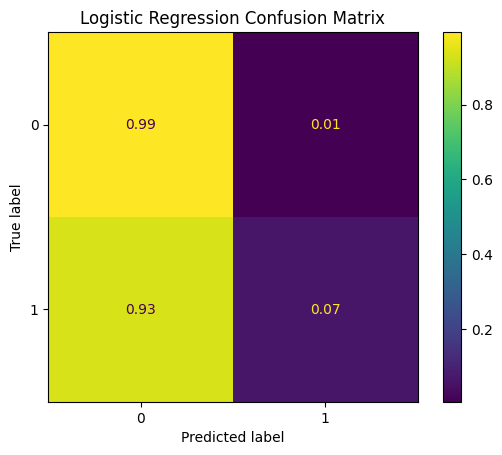

In [33]:
# fit logistic regression model
BNPL1_logit_model.fit(X_selected, y)
y_pred = BNPL1_logit_model.predict(X_selected)

# confusion matrix
BNPL1_logit_cm = confusion_matrix(y, y_pred, normalize='true')

# display cm
BNPL1_logit_cm_plot = ConfusionMatrixDisplay(confusion_matrix=BNPL1_logit_cm)
BNPL1_logit_cm_plot.plot(values_format=".2f")
plt.title('Logistic Regression Confusion Matrix')
plt.show()

comment: the logistic model has high false negatie score on predicting BNPL1=Yes. most of the predicted values go to "NO". re-run feature selection using resampled data.

## Resample data to balance target classes

In [34]:
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before:", Counter(y))

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("After:", Counter(y_resampled))

Before: Counter({0: 41725, 1: 5511})
After: Counter({0: 41725, 1: 41725})


In [ ]:
# repeat feature selection with recall
BNPL1_logit_model = LogisticRegression(C = 1, max_iter=2000) # high iterations with medium penalty

rfecv = RFECV(
    estimator=BNPL1_logit_model,
    step=1,
    cv=StratifiedKFold(5),
    scoring="recall"
)

rfecv.fit(X_resampled, y_resampled)

selected_features = X_resampled.columns[rfecv.support_]
print(selected_features)
print("Optimal number of features:", rfecv.n_features_)


Index(['B3_Much better off'], dtype='str')
Optimal number of features: 1


In [44]:
# view columns selection
pd.DataFrame({
    "feature": X_resampled.columns,
    "selected": rfecv.support_
})

,feature,selected
0,EF3_a,False
1,EF3_b,False
2,EF3_c,False
3,EF3_d,False
4,EF3_e,False
5,EF3_f,False
6,EF3_g,False
7,EF3_h,False
8,ppage,False
9,ppgender,False


In [47]:
# a glimpse of accuracy

X_selected = X_resampled[selected_features]

scores = cross_val_score(
    BNPL1_logit_model,
    X_selected,
    y_resampled,
    cv=5,
    scoring='recall'
)

print("CV recall:", scores)
print("Mean recall:", scores.mean())

CV recall: [0.95302576 0.98046735 0.98202516 0.98046735 0.98034751]
Mean recall: 0.9752666267225883


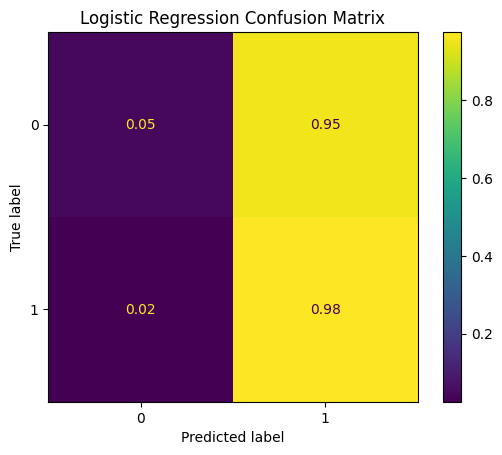

In [49]:
# fit logistic regression model
BNPL1_logit_model.fit(X_selected, y_resampled)
y_pred = BNPL1_logit_model.predict(X_selected)

# confusion matrix
BNPL1_logit_cm = confusion_matrix(y_resampled, y_pred, normalize='true')

# display cm
BNPL1_logit_cm_plot = ConfusionMatrixDisplay(confusion_matrix=BNPL1_logit_cm)
BNPL1_logit_cm_plot.plot(values_format=".2f")
plt.title('Logistic Regression Confusion Matrix')
plt.show()

comment: with resampled data, only one feature is selected, and the model predicts most of obs to class1 with the single feature fitting to the model. next, change scoring to F1 /accuracy in feature selection.

In [51]:
# repeat feature selection with f1
BNPL1_logit_model = LogisticRegression(max_iter=2000) # high iterations with medium penalty

rfecv = RFECV(
    estimator=BNPL1_logit_model,
    step=1,
    cv=StratifiedKFold(5),
    scoring="f1"
)

rfecv.fit(X_resampled, y_resampled)

selected_features = X_resampled.columns[rfecv.support_]
print(selected_features)
print("Optimal number of features:", rfecv.n_features_)


Index(['I20_Less than your income', 'I20_More than your income',
       'I20_The same as your income', 'ppeducat_Bachelor's degree or higher',
       'ppeducat_High school graduate (high school diploma or the equivalent GED)',
       'ppeducat_No high school diploma or GED',
       'ppeducat_Some college or Associate's degree',
       'ppethm_2+ Races, Non-Hispanic', 'ppethm_Black, Non-Hispanic',
       'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$10,000 to $24,999',
       'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more',
       'ppinc7_$25,000 to $49,999', 'ppinc7_$50,000 to $74,999',
       'ppinc7_$75,000 to $99,999', 'ppinc7_Less than $10,000',
       'ppemploy_Not working', 'ppemploy_Working full-time',
       'ppemploy_Working part-time', 'ppmarit5_Divorced',
       'ppmarit5_Never married', 'ppmarit5_Now married', 'ppmarit5_Separated',
       'ppmarit5_Widowed', 'ppagecat_18-24', 'ppagecat_25-34',
       'ppagecat_35-44'

In [52]:
# view columns selection
pd.DataFrame({
    "feature": X_resampled.columns,
    "selected": rfecv.support_
})

,feature,selected
0,EF3_a,False
1,EF3_b,False
2,EF3_c,False
3,EF3_d,False
4,EF3_e,False
5,EF3_f,False
6,EF3_g,False
7,EF3_h,False
8,ppage,False
9,ppgender,False


In [54]:
# a glimpse of accuracy

X_selected = X_resampled[selected_features]

scores = cross_val_score(
    BNPL1_logit_model,
    X_selected,
    y_resampled,
    cv=5,
    scoring='accuracy'
)

print("CV accuracy:", scores)
print("Mean accuracy:", scores.mean())

CV accuracy: [0.66225285 0.97765129 0.97783104 0.97519473 0.97513481]
Mean accuracy: 0.9136129418813661


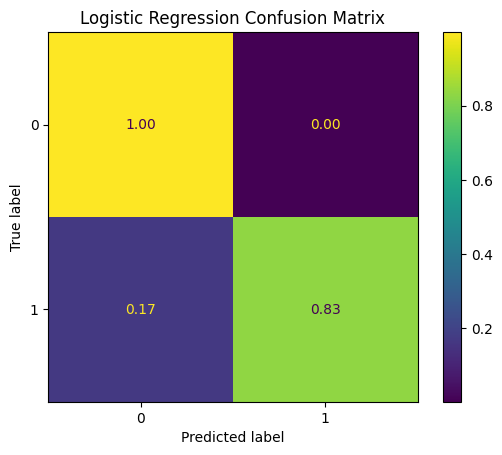

In [ ]:
# fit logistic regression model
BNPL1_logit_model.fit(X_selected, y_resampled)
y_pred = BNPL1_logit_model.predict(X_selected)

# confusion matrix
BNPL1_logit_cm = confusion_matrix(y_resampled, y_pred, normalize='true')

# display cm
BNPL1_logit_cm_plot = ConfusionMatrixDisplay(confusion_matrix=BNPL1_logit_cm)
BNPL1_logit_cm_plot.plot(values_format=".2f")
plt.title('Logistic Regression Confusion Matrix')
plt.show()

comment: now we get a very good model predictive accurcy.

## Feature selection using SVC model

In [57]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

In [58]:
rfecv = RFECV(
    estimator=LinearSVC(max_iter=5000),
    step=1,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring="f1"
)

rfecv.fit(X_resampled, y_resampled)

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LinearSVC(max_iter=5000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'f1'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and opt

In [59]:
selected_features = X_resampled.columns[rfecv.support_]
print(selected_features)
print("Optimal number of features:", rfecv.n_features_)

# view columns selection
pd.DataFrame({
    "feature": X_resampled.columns,
    "selected": rfecv.support_
})

Index(['EF3_d', 'EF3_f', 'I20_Less than your income',
       'I20_More than your income', 'I20_The same as your income',
       'ppeducat_Bachelor's degree or higher',
       'ppeducat_High school graduate (high school diploma or the equivalent GED)',
       'ppeducat_No high school diploma or GED',
       'ppeducat_Some college or Associate's degree',
       'ppethm_2+ Races, Non-Hispanic', 'ppethm_Black, Non-Hispanic',
       'ppethm_Hispanic', 'ppethm_Other, Non-Hispanic',
       'ppethm_White, Non-Hispanic', 'ppinc7_$10,000 to $24,999',
       'ppinc7_$100,000 to $149,999', 'ppinc7_$150,000 or more',
       'ppinc7_$25,000 to $49,999', 'ppinc7_$50,000 to $74,999',
       'ppinc7_$75,000 to $99,999', 'ppinc7_Less than $10,000',
       'ppemploy_Not working', 'ppemploy_Working full-time',
       'ppemploy_Working part-time', 'ppmarit5_Divorced',
       'ppmarit5_Never married', 'ppmarit5_Now married', 'ppmarit5_Separated',
       'ppmarit5_Widowed', 'ppagecat_18-24', 'ppagecat_25-34'

,feature,selected
0,EF3_a,False
1,EF3_b,False
2,EF3_c,False
3,EF3_d,True
4,EF3_e,False
5,EF3_f,True
6,EF3_g,False
7,EF3_h,False
8,ppage,False
9,ppgender,False


In [60]:
# a glimpse of accuracy
BNPL1_svc_model=LinearSVC(max_iter=5000)

X_selected = X_resampled[selected_features]

scores = cross_val_score(
    BNPL1_svc_model,
    X_selected,
    y_resampled,
    cv=5,
    scoring='accuracy'
)

print("CV accuracy:", scores)
print("Mean accuracy:", scores.mean())

CV accuracy: [0.66225285 0.97741162 0.97795087 0.9758538  0.97555422]
Mean accuracy: 0.9138046734571601


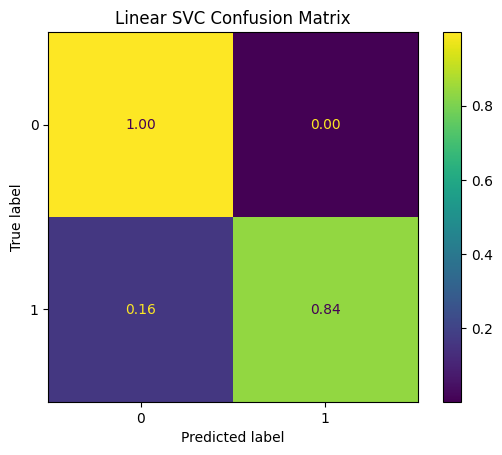

In [61]:
# fit logistic regression model
BNPL1_svc_model.fit(X_selected, y_resampled)
y_pred = BNPL1_svc_model.predict(X_selected)

# confusion matrix
BNPL1_svc_cm = confusion_matrix(y_resampled, y_pred, normalize='true')

# display cm
BNPL1_svc_cm_plot = ConfusionMatrixDisplay(confusion_matrix=BNPL1_svc_cm)
BNPL1_svc_cm_plot.plot(values_format=".2f")
plt.title('Linear SVC Confusion Matrix')
plt.show()

comment: good accuracy using Linear SVC model. 